# Business Insights & Executive Summary

Author: Your Name

Project: Marketing Campaign Optimization

Objective:
Translate statistical analysis into actionable business recommendations for stakeholders.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\win10\OneDrive\Desktop\Data-Projects\Portfolio Project\ab-testing-regression-project\01_Data\cleaned_marketing_campaign.csv')
ab_summary = pd.read_csv(r'C:\Users\win10\OneDrive\Desktop\Data-Projects\Portfolio Project\ab-testing-regression-project\01_Data\ab_testing_summary.csv')
predictions = pd.read_csv(r'C:\Users\win10\OneDrive\Desktop\Data-Projects\Portfolio Project\ab-testing-regression-project\01_Data\regression_predictions.csv')
feature_importance = pd.read_csv(r'C:\Users\win10\OneDrive\Desktop\Data-Projects\Portfolio Project\ab-testing-regression-project\01_Data\feature_importance.csv')

In [3]:
total_revenue = df['Revenue'].sum()
print("Total Revenue:", round(total_revenue,2))

Total Revenue: 2788316.62


In [4]:
total_conversions = df['Conversions'].sum()
print("Total Conversions:", total_conversions)

Total Conversions: 30856


In [5]:
total_spend = df['Ad_Spend'].sum()
print("Total Ad Spend:", round(total_spend,2))

Total Ad Spend: 561896.9


In [6]:
# Return On investment 
roi = ((total_revenue - total_spend)/ total_spend)* 100
print("ROI:", round(roi, 2), "%")

ROI: 396.23 %


In [8]:
# Average Conversion Rate
avg_conversion = df['Conversion_Rate'].sum()
print("Average Conversion Rate:", round(avg_conversion, 2)) 

Average Conversion Rate: 7128.24


In [9]:
kpi_summary = pd.DataFrame({'Metric': ['Total Revenue','Total Ad Spend','Total Conversions','Average Conversion Rate','ROI'],
    'Value': [total_revenue,total_spend,total_conversions,avg_conversion,roi]})
kpi_summary

,Metric,Value
0,Total Revenue,2.788317e+06
1,Total Ad Spend,5.618969e+05
2,Total Conversions,3.085600e+04
3,Average Conversion Rate,7.128239e+03
4,ROI,3.962328e+02


In [16]:
platform_revenue = df.groupby('Platform')['Revenue'].sum()
platform_revenue

Platform
facebook    1.309339e+06
google      1.478978e+06
Name: Revenue, dtype: float64

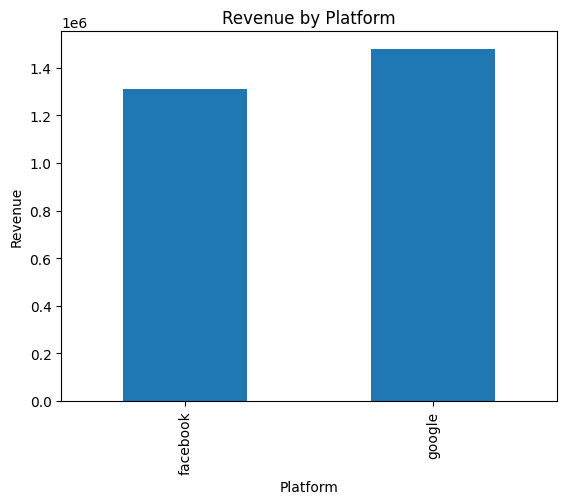

In [17]:
platform_revenue.plot(kind="bar")
plt.title('Revenue by Platform')
plt.ylabel('Revenue')
plt.show()

In [18]:
platform_conversion = df.groupby('Platform')['Conversion_Rate'].mean()
platform_conversion

Platform
facebook    6.006343
google      7.990044
Name: Conversion_Rate, dtype: float64

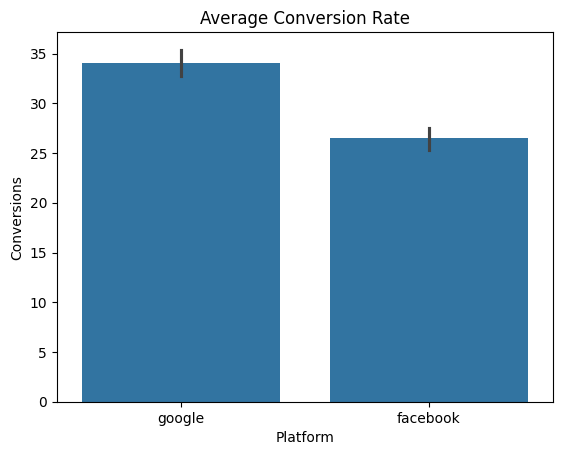

In [20]:
sns.barplot(data=df, x='Platform', y='Conversions')
plt.title("Average Conversion Rate")
plt.show()

In [21]:
df['Date'] = pd.to_datetime(df['Date'])

In [22]:
weekly_revenue = df.groupby(pd.Grouper(key="Date", freq="W"))['Revenue'].sum()

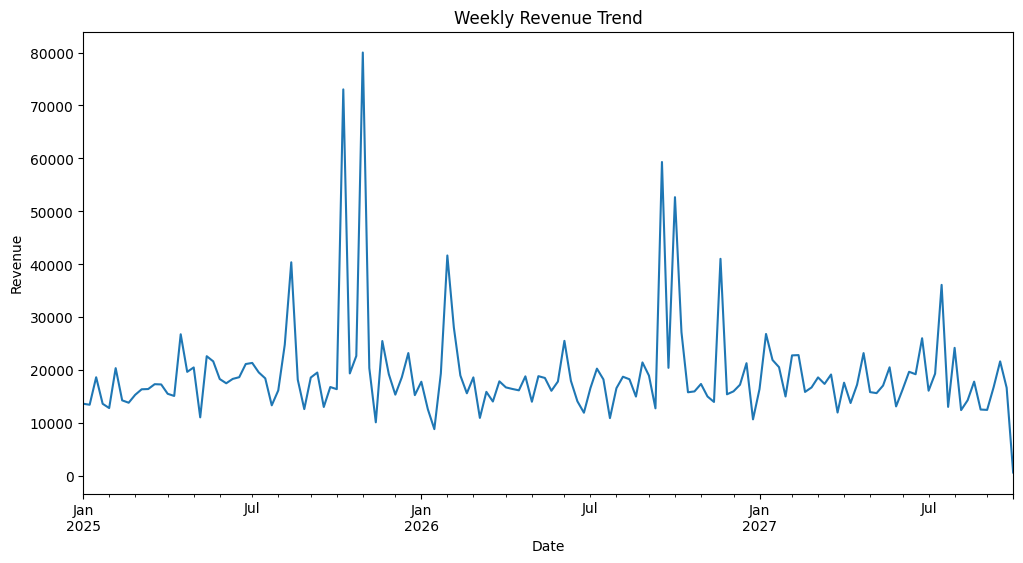

In [24]:
plt.figure(figsize=(12,6))
weekly_revenue.plot()
plt.title('Weekly Revenue Trend')
plt.ylabel('Revenue')
plt.show()

# Weekly Trend Insight

Weekly revenue trends help stakeholders identify:
- Peak campaign periods
- Seasonal performance
- Revenue fluctuations
- Budget optimization opportunities

In [25]:
feature_importance

,Feature,Coefficient
0,Ad_Spend,-0.000194
1,Impressions,0.002174
2,Clicks,0.044532
3,CTR,1.598067


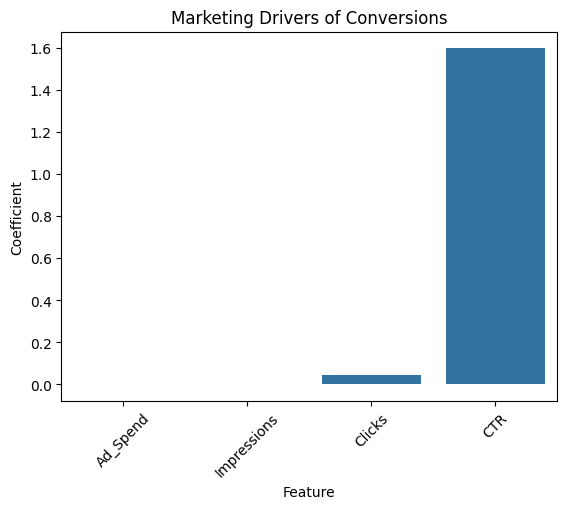

In [26]:
sns.barplot(data=feature_importance, x='Feature', y='Coefficient')
plt.title('Marketing Drivers of Conversions')
plt.xticks(rotation=45)
plt.show()

# Regression Insight

The regression model indicates that:
- Clicks are the strongest driver of conversions.
- CTR significantly impacts campaign success.
- Ad spend alone has weaker influence compared to engagement metrics.

Business implication:
The company should optimize ad quality and targeting instead of simply increasing budget.

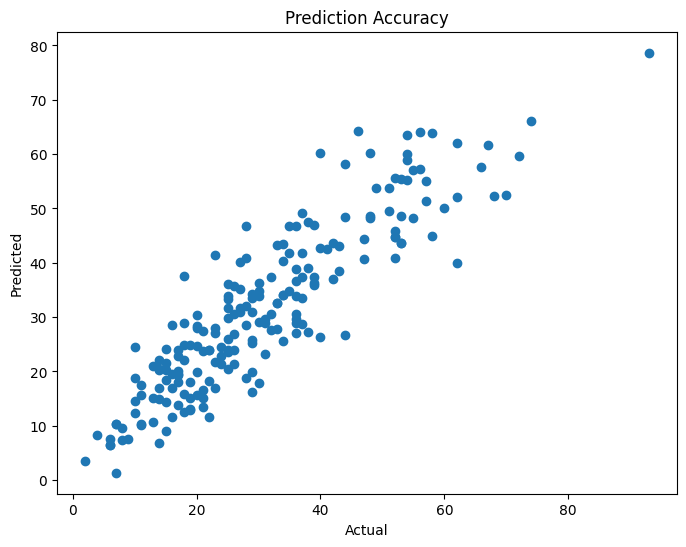

In [27]:
# Actual VS Predicted Performance

plt.figure(figsize=(8,6))
plt.scatter(predictions['Actual'], predictions['Predicted'])
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Prediction Accuracy')
plt.show()

# Prediction Insight

The regression model demonstrates strong predictive performance.

This enables the marketing team to:
- Forecast future campaign performance
- Estimate conversions before launching campaigns
- Improve budget allocation decisions

# Executive Summary

## Key Findings

1. Google Ads outperformed Facebook Ads in conversion rates.

2. A/B testing confirmed the performance difference is statistically significant.

3. Click-through rate and clicks are the strongest predictors of conversions.

4. Higher ad spend does not automatically generate better results.

5. ROI analysis indicates campaign profitability.

## Strategic Recommendations

- Allocate higher budget toward Google Ads campaigns.
- Improve targeting and ad creatives to increase CTR.
- Monitor weekly campaign trends for optimization opportunities.
- Use predictive analytics before scaling campaigns.

# Recommendations for Stakeholders

## Marketing Team
Focus on improving user engagement metrics such as CTR.

## Finance Team
Prioritize campaigns with higher ROI rather than higher spending.

## Executive Leadership
Invest in predictive analytics for future campaign planning.

## Operations Team
Create automated reporting dashboards for weekly monitoring.

In [28]:
kpi_summary.to_csv('kpi_summary.csv', index=False)

In [29]:
weekly_revenue.to_csv('weekly_revenue.csv')

# Final Project Conclusion

This project successfully demonstrated how statistical analysis and predictive modeling can improve marketing decision-making.

Using A/B testing and regression analysis:
- High-performing platforms were identified.
- Conversion drivers were discovered.
- Predictive insights were generated.

The project highlights the importance of combining analytics, statistics, and business strategy to optimize marketing performance.